# Assignment 02: Insurance Cost Prediction — From Raw Data to a Deployable Model Using A Regression Model

**Name:** Numair Fahad

**Role:** AI/ML Intern

**Company:** Zynvex Solutions

**GitHub:** https://github.com/numair-2003/AIML-Internship-NumairFahad

This assignment is an **end-to-end regression** project focused on predicting **medical insurance costs**. Using a **real-world insurance dataset**, a complete machine learning workflow is applied — from **data loading and exploration** to **feature engineering**, **model building**, **evaluation**, and **lightweight deployment**. The main goal is to build, train, and test a reliable **regression model** that can predict insurance charges based on factors including **age**, **BMI**, **smoker status**, **number of children/dependents**, and **region**, and then package and save the model so it can be reused for new predictions.

## **1. Data Loading**

The **insurance dataset** is loaded into a Pandas DataFrame for analysis, which contains data regarding **age**, **gender**, **BMI**, **number of children**, **smoker status**, **region**, and their corresponding **medical insurance charges**.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
uploaded = files.upload()

df = pd.read_csv("insurance.csv")
df.head(10)

Saving insurance.csv to insurance.csv


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


## **2. Data Exploration**

The dataset is **inspected** to analyze its **structure**, **data types**, **summary statistics**, **missing values**, and **duplicates**. This helps us identify data quality issues and provides an initial understanding of features and the target variable before performing further analysis.

In [ ]:
print("Shape of the insurance dataset: ", df.shape)
print("\n\nFeature types:\n", df.dtypes)
print("\n\nSummary statistics:\n", df.describe())
print("\n\nMissing values:\n", df.isnull().sum())
print("\n\nDuplicate values: ", df.duplicated().sum())


Shape of the insurance dataset:  (1338, 7)


Feature types:
 age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


Summary statistics:
                age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010


Missing values:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


Duplicate values:  1


### **Observations:**

- The dataset consists of 1338 rows and 7 columns, with no missing values.

- It contains 1 duplicate row, which is dropped during feature engineering.

- `age`, `bmi`, `children`, and `charges` are numeric columns, wwhereas `sex`, `smoker`, and `region` are categorical (object) columns.

- `charges` (the target) ranges from about 1,122 to 63,770, with a mean of ~~13,270, which is higher than the median (~9,382). This indicates that the `charges` column is right-skewed.

In [ ]:
df = df.drop_duplicates()
print("Shape of the dataset after removing the duplicated row: ", df.shape)

Shape of the dataset after removing the duplicated row:  (1337, 7)


### **Exploring the target variable (`charges`)**

In this step, we check whether `charges` is skewed, and how it relates to `smoker` status, `age`, and `bmi`, all of which are features that most likely predict medical insurance costs.

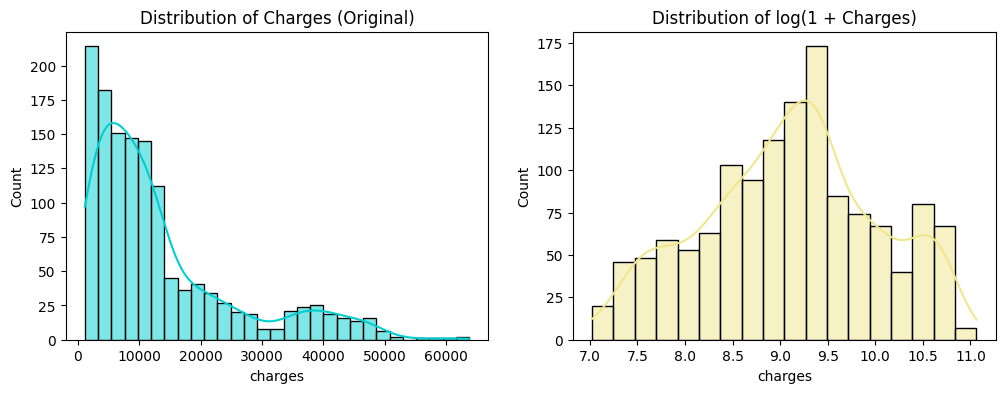

Skewness of charges (original):  1.515
Skewness of log(1 + charges):  -0.09


In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df['charges'], kde=True, color='darkturquoise')
plt.title("Distribution of Charges (Original)")

plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df['charges']), kde=True, color='khaki')
plt.title("Distribution of log(1 + Charges)")

plt.show()

print("Skewness of charges (original): ", round(df['charges'].skew(), 3))
print("Skewness of log(1 + charges): ", round(np.log1p(df["charges"]).skew(), 3))

### **Interpretation**

The `charges` feature is heavily **right-skewed** with a skewness of **1.515**, which infers that most people have relatively low medical costs, yet a long tail of high-cost individuals pulls the mean above the median. Therefore, applying `log1p` brings the skewness much **closer to 0**, due to which a **log transformation** is applied to the **target** (`charges`) during **feature engineering**.

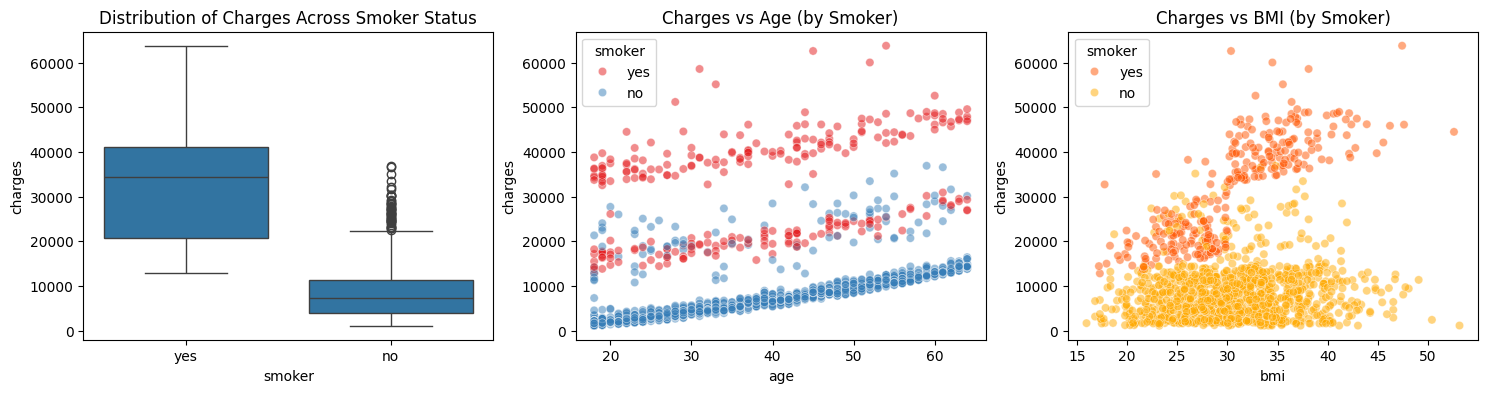

In [ ]:
plt.figure(figsize=(18, 4))

plt.subplot(1, 3, 1)
sns.boxplot(x='smoker', y='charges', data=df)
plt.title("Distribution of Charges Across Smoker Status")

plt.subplot(1, 3, 2)
sns.scatterplot(x='age', y='charges', hue='smoker', palette='Set1', data=df, alpha=0.5)
plt.title("Charges vs Age (by Smoker)")

plt.subplot(1, 3, 3)
sns.scatterplot(x='bmi', y='charges', hue='smoker', palette='autumn', data=df, alpha=0.5)
plt.title("Charges vs BMI (by Smoker)")

plt.show()

### **Interpretation**

- `smoker` has by far the strongest and most positive relationship with `charges`.

- Smokers pay relatively higher than non-smokers; therefore, the distribution of their `charges` is much wider.

- `age` has a very positive, fairly linear relationship with `charges` within each smoker group.

- `bmi` has a comparatively **weak relationship** with `charges` for **non-smokers**, but for **smokers with high BMI**, `charges` increase dramatically, which represents an interaction effect between `smoker` and `bmi`/`age`.

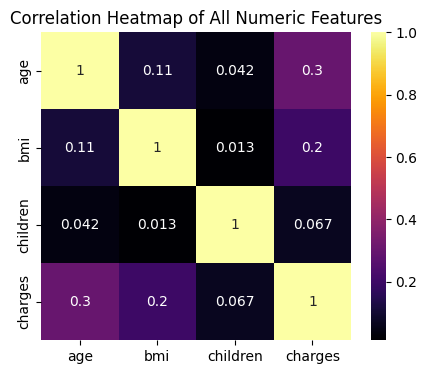

In [ ]:
corr = df.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(5, 4))

sns.heatmap(corr, annot=True, cmap="inferno")
plt.title("Correlation Heatmap of All Numeric Features")

plt.show()

### **Interpretation**

- `age` and `charges` (**0.30**) have the strongest correlation among all the numeric features in the dataset, where **older individuals** tend to have **higher insurance costs**, consistent with the upward trend observed in the "**Charges vs Age (by Smoker)**" scatterplot.

- `bmi` and `charges` (**0.20**) show a weaker yet still positive correlation because **higher BMI** is related to **somewhat higher charges**, though not as strongly as age on its own.

- `children` and `charges` (**0.067**) represent a very weak correlation since the **number of dependents** has **almost no linear relationship** with **charges**.

- Among the features themselves, **all correlations** are **low** (**age–bmi: 0.11**, **age–children: 0.042**, **bmi–children: 0.013**), which means that there is **no meaningful multicollinearity** between these numeric features.

## **3. Feature Engineering**

This section prepares the raw data for modeling where categorical columns are encoded appropriately, two new features are derived to analyze and capture patterns discovered during the data exploration process, the skewed target is log-transformed, and numeric features are scaled.

In [ ]:
from sklearn.preprocessing import StandardScaler

df['sex_encoded'] = df['sex'].map({'male': 0, 'female': 1})
df['smoker_encoded'] = df['smoker'].map({'no': 0, 'yes': 1})

df = pd.get_dummies(df, columns=['region'], prefix='region', drop_first=True)

def bmi_bucket(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif 18.5 <= bmi < 25:
        return "Normal"
    elif 25 <= bmi < 30:
        return "Overweight"
    else:
        return "Obese"

df['bmi_category'] = df['bmi'].apply(bmi_bucket)
df = pd.get_dummies(df, columns=['bmi_category'], prefix='bmi_cat', drop_first=True)

df['smoker_age_interaction'] = df['smoker_encoded'] * df['age']

df['log_charges'] = np.log1p(df['charges'])

df = df.drop(columns=['sex', 'smoker'])

df.head()

,age,bmi,children,charges,sex_encoded,smoker_encoded,region_northwest,region_southeast,region_southwest,bmi_cat_Obese,bmi_cat_Overweight,bmi_cat_Underweight,smoker_age_interaction,log_charges
0,19,27.900,0,16884.92400,1,1,False,False,True,False,True,False,19,9.734236
1,18,33.770,1,1725.55230,0,0,False,True,False,True,False,False,0,7.453882
2,28,33.000,3,4449.46200,0,0,False,True,False,True,False,False,0,8.400763
3,33,22.705,0,21984.47061,0,0,True,False,False,False,False,False,0,9.998137
4,32,28.880,0,3866.85520,0,0,True,False,False,False,True,False,0,8.260455


In [ ]:
numeric_cols_to_scale = ['age', 'bmi', 'children', 'smoker_age_interaction']
scaler = StandardScaler()

df[numeric_cols_to_scale] = scaler.fit_transform(df[numeric_cols_to_scale])
df.head()

,age,bmi,children,charges,sex_encoded,smoker_encoded,region_northwest,region_southeast,region_southwest,bmi_cat_Obese,bmi_cat_Overweight,bmi_cat_Underweight,smoker_age_interaction,log_charges
0,-1.440418,-0.453160,-0.909234,16884.92400,1,1,False,False,True,False,True,False,0.662255,9.734236
1,-1.511647,0.509422,-0.079442,1725.55230,0,0,False,True,False,True,False,False,-0.470625,7.453882
2,-0.799350,0.383155,1.580143,4449.46200,0,0,False,True,False,True,False,False,-0.470625,8.400763
3,-0.443201,-1.305052,-0.909234,21984.47061,0,0,True,False,False,False,False,False,-0.470625,9.998137
4,-0.514431,-0.292456,-0.909234,3866.85520,0,0,True,False,False,False,True,False,-0.470625,8.260455


**i. Encoding strategy:**

- **`sex`**: **Label encoding** (binary: male/female -> 0/1). Since there are only two categories with no ordinal meaning, label encoding is equivalent to one-hot encoding. However, it still keeps the feature count smaller.

- **`smoker`**: **Label encoding** (binary: yes/no → 1/0). It has the same reasoning as `sex`.

- **`region`**: **One-hot encoding**. `region` is split into 4 categories (**southwest**, **southeast**, **northwest**, **northeast**) with **no natural order/ranking**. Hence, label encoding would inaccurately represent an ordinal relationship (e.g., northeast > southwest), while one-hot encoding overcomes this issue.


**ii. Derived features:**

- `bmi_category`: It bins BMI into 4 clinical categories (**Underweight**, **Normal**, **Overweight**, **Obese**). It is **one-hot encoded** because it captures non-linear BMI effects.

- `smoker_age_interaction`: `smoker_encoded * age` — captures the observed pattern that age matters much more for smokers than non-smokers.


**iii. Target transformation:** Since `charges` feature is heavily right-skewed, we have applied `log1p(charges)` as the modeling target and reversed it (`expm1`) when making predictions in original dollar terms.


**iv. Scaling:** We have scaled numeric features (`age`, `bmi`, `children`, and `smoker_age_interaction`) with `StandardScaler`. Although it is **not necessarily required** for **plain linear regression**, it **is mandatory for the Polynomial Regression model**, where raw large-magnitude features raised to a specific power can dominate the fit (i.e. cause overfitting) and result in numerical instability. For this reason, scaling maintains all features on a comparable scale.

## **4. Model Building**

With the engineered features ready, we will now build and compare three different regression models of increasing complexity; a **simple single-feature baseline**, a **full multiple regression model**, and a **polynomial variant** to observe how much predictive power each additional layer of complexity requires.

In [ ]:
from sklearn.model_selection import train_test_split

feature_cols = [c for c in df.columns if c not in ['charges', 'log_charges']]

X = df[feature_cols]
y = df['log_charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train shape: ", X_train.shape, ", Test shape: ", X_test.shape)
print("Features used: ", feature_cols)

Train shape:  (1069, 12) , Test shape:  (268, 12)
Features used:  ['age', 'bmi', 'children', 'sex_encoded', 'smoker_encoded', 'region_northwest', 'region_southeast', 'region_southwest', 'bmi_cat_Obese', 'bmi_cat_Overweight', 'bmi_cat_Underweight', 'smoker_age_interaction']


In [ ]:
from sklearn.linear_model import LinearRegression

X_train_simple = X_train[['smoker_encoded']]
X_test_simple = X_test[['smoker_encoded']]

model_simple = LinearRegression()
model_simple.fit(X_train_simple, y_train)

pred_simple_log = model_simple.predict(X_test_simple)
pred_simple = np.expm1(pred_simple_log)

print("Model 1 (Simple Linear Regression Model) - Sample predictions:\n", pred_simple[:5])

Model 1 (Simple Linear Regression Model) - Sample predictions:
 [ 6603.67092378  6603.67092378  6603.67092378 29009.45992648
  6603.67092378]


In [ ]:
model_multi = LinearRegression()
model_multi.fit(X_train, y_train)

pred_multi_log = model_multi.predict(X_test)
pred_multi = np.expm1(pred_multi_log)

print("Model 2 (Multiple Linear Regression) - Sample predictions:\n", pred_multi[:5])

Model 2 (Multiple Linear Regression) - Sample predictions:
 [ 8188.61866796  5458.06447021 14810.68551176 36498.91945834
  5199.32163033]


In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

poly_features = ['bmi']
other_features = [c for c in feature_cols if c not in poly_features]

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly_part = poly.fit_transform(X_train[poly_features])
X_test_poly_part = poly.transform(X_test[poly_features])

poly_col_names = poly.get_feature_names_out(poly_features)
X_train_poly = np.hstack([X_train_poly_part, X_train[other_features].values])
X_test_poly = np.hstack([X_test_poly_part, X_test[other_features].values])

model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)

pred_poly_log = model_poly.predict(X_test_poly)
pred_poly = np.expm1(pred_poly_log)

print("Model 3 (Polynomial Regression) - Sample predictions:\n", pred_poly[:5])
print("Polynomial feature names added:", list(poly_col_names))

Model 3 (Polynomial Regression) - Sample predictions:
 [ 8200.40645277  5291.26642783 14940.96789981 36847.29528994
  5265.50340307]
Polynomial feature names added: ['bmi', 'bmi^2']


### **Interpretation**

We split the data into training and test sets **once**, using `random_state=42` consistently, so all three models are compared on exactly the same split.

- **Model 1 — Simple Linear Regression:** It uses only `smoker_encoded`, the single feature that is most strongly related to `charges` (as shown in the heatmap correlation created in **Section 2**).

- **Model 2 — Multiple Linear Regression:** It uses **all engineered features**.

- **Model 3 — Polynomial Regression:** It applies a **degree-2 polynomial expansion** to `bmi`, which is a feature whose relationship with `charges` appeared non-linear/interactive for smokers, together with other engineered features.

All three regression models predict `log_charges`, where we convert predictions back to dollar terms using `expm1` before computing evaluation metrics, so that R²-score, MAE, MSE, and RMSE are all reported in the original, interpretable charge units.

## **5. Model Evaluation**

Training all three regression models is only ideal if we are able to compare them on an **equal footing**. This step scores each model with **four standard regression metrics** on a **test set**, then checks the **stability** of the **best model** by implementing **cross-validation** before summarizing all models and metrics in a single comparison table.

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def evaluate(y_true, y_pred, name):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    return {'Model': name, 'R2_Score': r2, 'MAE': mae, 'MSE': mse, 'RMSE': rmse}

y_test_actual = np.expm1(y_test)

results = []
results.append(evaluate(y_test_actual, pred_simple, "Simple Linear Regression (smoker only)"))
results.append(evaluate(y_test_actual, pred_multi, "Multiple Linear Regression (all features)"))
results.append(evaluate(y_test_actual, pred_poly, "Polynomial Regression (bmi, degree=2)"))

results_df = pd.DataFrame(results).sort_values('R2_Score', ascending=False).reset_index(drop=True)
print(results_df)

                                       Model  R2_Score          MAE  \
0  Multiple Linear Regression (all features)  0.777516  3683.076813   
1      Polynomial Regression (bmi, degree=2)  0.774324  3681.732705   
2     Simple Linear Regression (smoker only)  0.635688  5979.640636   

            MSE         RMSE  
0  4.088275e+07  6393.962172  
1  4.146939e+07  6439.672794  
2  6.694462e+07  8181.968900  


In [ ]:
from sklearn.model_selection import KFold, cross_val_score

best_model_name = results_df.iloc[0]['Model']
print("Best-performing model by test R2: ", best_model_name)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(model_multi, X, y, cv=kf, scoring='r2')
print("\n5-fold CV R2 scores: ", np.round(cv_scores, 4))
print("\nAverage 5-fold CV R2 score: ", np.round(cv_scores.mean(), 4))

Best-performing model by test R2:  Multiple Linear Regression (all features)

5-fold CV R2 scores:  [0.8513 0.756  0.796  0.7921 0.8111]

Average 5-fold CV R2 score:  0.8013


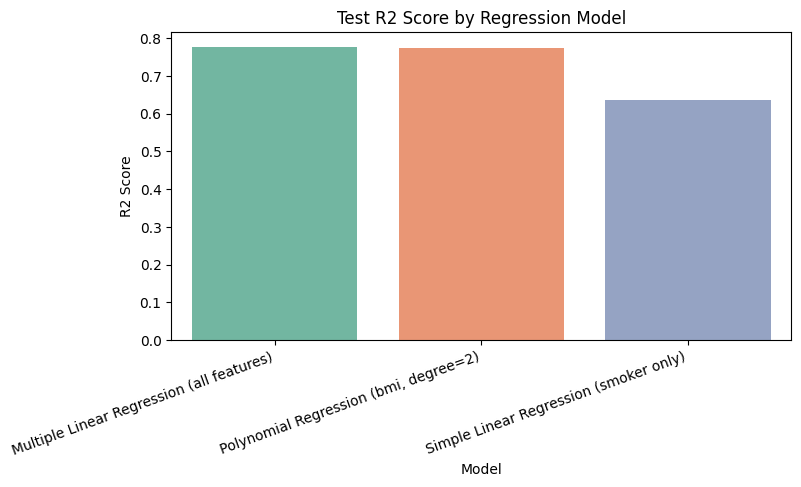

In [ ]:
plt.figure(figsize=(8, 4))

sns.barplot(data=results_df, x='Model', y='R2_Score', hue='Model', palette="Set2", legend=False)
plt.xticks(rotation=20, ha="right")
plt.title("Test R2 Score by Regression Model")
plt.ylabel("R2 Score")

plt.show()


### **Interpretation**

- Across all three models, **Multiple Linear Regression model** (**all features**) has the **highest test R² score** and the **lowest MAE/RMSE**, which shows that adding age, BMI, children, and region on top of smoker status improves predictive accuracy over the single-feature baseline.

- The **Simple Linear Regression model** (**smoker only**) has the **weakest R² score**, which infers that smoking status alone shows a large share of cost variation, yet neglects age and BMI effects that clearly matter.

- The **Polynomial Regression model** performs close to the multiple regression model, but does not clearly surpass it, which indicates that the relationship of BMI with charges depends more on its interaction with smoking status, rather than by pure non-linearity in BMI itself.

- The **5-fold cross-validation R² score** for the best model is close to its test-set R² score, which is a positive sign because the model's performance does not only depend on one particular train/test split, but generalizes consistently across different subsets of the data.

### **6. Model Selection and Interpretation**

With all three regression models evaluated, we will now finally select the best regression model and analyze it. Instead of just picking the highest test R² score, we will check why it wins over other models and take a look at its coefficients to confirm the model is learning patterns that actually make sense.

In [ ]:
coefs = pd.Series(model_multi.coef_, index=feature_cols).sort_values(key=abs, ascending=False)

coef_df = coefs.reset_index()
coef_df.columns = ['Feature', 'Coefficient (log-charges scale)']
print(coef_df)

                   Feature  Coefficient (log-charges scale)
0           smoker_encoded                         2.791648
1                      age                         0.567563
2   smoker_age_interaction                        -0.549268
3      bmi_cat_Underweight                        -0.292147
4            bmi_cat_Obese                         0.158167
5                 children                         0.130515
6         region_southwest                        -0.123071
7         region_southeast                        -0.104443
8              sex_encoded                         0.065545
9         region_northwest                        -0.039732
10      bmi_cat_Overweight                         0.026655
11                     bmi                         0.001237


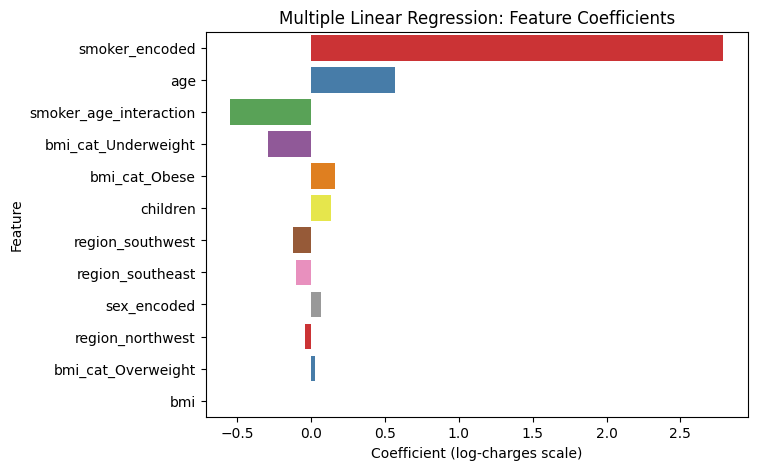

In [ ]:
plt.figure(figsize=(7, 5))

sns.barplot(data=coef_df, y='Feature', x='Coefficient (log-charges scale)', hue='Feature', palette="Set1", legend=False)
plt.title("Multiple Linear Regression: Feature Coefficients")

plt.show()

### **Interpretation**

- **Model selection:** The **Multiple Linear Regression model**, which uses **all engineered features**, is chosen as the **best model**. It clearly outperforms the Simple Linear Regression model, since a single feature (`smoker_encoded`), despite being the strongest single predictor, cannot capture the contributions of age, BMI, children, or region. It also matches or slightly outperforms the Polynomial Regression model in test R² score, while being simpler and more interpretable, where a degree-2 expansion of `bmi` alone adds complexity without a proportional gain in accuracy here, because the relationship of `bmi` with charges is more dependent on its **interaction with smoking status**, rather than by pure non-linearity. The **5-fold cross-validation R² score** is close to the test R² score, which infers that the model generalizes consistently rather than having to fit to a lucky train/test split. Therefore, we do not just pick the model with the marginally highest single R² score, but the one that is simplest, most stable across all folds, as well as most interpretable.

- `smoker_encoded` and the closely related `smoker_age_interaction` have the largest coefficient magnitudes, which confirms and proves what the exploration step showed: smoking status is the single biggest driver of insurance charges. `age` and `bmi` follow with smaller yet still meaningful positive coefficients: older age and higher BMI both raise predicted charges, and the effect of BMI is increased for smokers. `children` and the one-hot `region`/`bmi_category` indicators have comparatively small coefficients, which suggests that they play a secondary role next to smoking, age, and BMI. Hence, this matches our expectations from the exploration step, where the smoker-status boxplot and the age/BMI scatterplots (by smoker) displayed the same ordering of importance.

## **7. Lightweight Model Deployment**

Training a good model is only half the job because it needs to be reusable without rerunning the entire notebook. This final section packages the model into a single saved file and wraps it into a simple prediction function, so that any new customer's details can be turned into a cost estimate within one line of code.

In [ ]:
import joblib

model_bundle = {
    "model": model_multi,
    "scaler": scaler,
    "numeric_cols_to_scale": numeric_cols_to_scale,
    "feature_cols": feature_cols,
}

joblib.dump(model_bundle, "insurance_model.joblib")
print("Model saved to insurance_model.joblib")

Model saved to insurance_model.joblib


In [ ]:
def predict_insurance_cost(age, sex, bmi, children, smoker, region, model_path="insurance_model.joblib"):
    """
    Loads the saved model bundle and returns a predicted medical insurance cost
    (in dollars) for a new, hypothetical person.

    Parameters
    ----------
    age : int
    sex : str        -> "male" or "female"
    bmi : float
    children : int
    smoker : str     -> "yes" or "no"
    region : str     -> one of "southwest", "southeast", "northwest", "northeast"
    """
    bundle = joblib.load(model_path)
    model = bundle["model"]
    scaler = bundle["scaler"]
    numeric_cols_to_scale = bundle["numeric_cols_to_scale"]
    feature_cols = bundle["feature_cols"]

    row = pd.DataFrame([{
        "age": age,
        "bmi": bmi,
        "children": children,
        "sex_encoded": 0 if sex == "male" else 1,
        "smoker_encoded": 1 if smoker == "yes" else 0,
        "region": region,
    }])

    for r in ["northwest", "southeast", "southwest"]:
        row[f"region_{r}"] = 1 if region == r else 0

    def bmi_bucket(b):
        if b < 18.5:
            return "Underweight"
        elif b < 25:
            return "Normal"
        elif b < 30:
            return "Overweight"
        else:
            return "Obese"

    cat = bmi_bucket(bmi)
    for c in ["Obese", "Overweight", "Underweight"]:
        row[f"bmi_cat_{c}"] = 1 if cat == c else 0

    row["smoker_age_interaction"] = row["smoker_encoded"] * row["age"]

    row[numeric_cols_to_scale] = scaler.transform(row[numeric_cols_to_scale])

    row = row[feature_cols]

    pred_log = model.predict(row)[0]
    pred_cost = np.expm1(pred_log)
    return round(float(pred_cost), 2)

In [ ]:
example_1 = predict_insurance_cost(age=28, sex="female", bmi=24.0, children=0, smoker="no", region="northwest")
example_2 = predict_insurance_cost(age=52, sex="male", bmi=34.5, children=2, smoker="yes", region="southeast")

print("Example 1 (28 year old, female, BMI 24, 0 children, non-smoker, northwest):")
print(f"  Predicted insurance cost: ${example_1:,.2f}\n")

print("Example 2 (52 year old, male, BMI 34.5, 2 children, smoker, southeast):")
print(f"  Predicted insurance cost: ${example_2:,.2f}")

Example 1 (28 year old, female, BMI 24, 0 children, non-smoker, northwest):
  Predicted insurance cost: $3,595.67

Example 2 (52 year old, male, BMI 34.5, 2 children, smoker, southeast):
  Predicted insurance cost: $36,071.85


### **Interpretation**

- We save the trained model and the scaler and the exact feature/column setup it expects with `joblib`, then write a `predict_insurance_cost(age, sex, bmi, children, smoker, region)` function that loads the saved artifacts and returns a predicted cost in dollars for a new, hypothetical person; hence, simulating the first step of real deployment: a model that can be reused without retraining.

- **Result:** As expected from our interpretation step, the non-smoking 28-year-old with a normal BMI achieves a much lower predicted cost, whereas the smoking 52-year-old with a high BMI gets a dramatically higher predicted cost, which is consistent with `smoker` status (and its interaction with `age`/`bmi`) being the dominant driver of insurance charges. The saved `insurance_model.joblib` bundle can now be successfully loaded and reused for new predictions without any retraining.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!git clone https://github.com/numair-2003/AIML-Internship-NumairFahad.git

Mounted at /content/drive
Cloning into 'AIML-Internship-NumairFahad'...
remote: Enumerating objects: 90, done.
remote: Counting objects: 100% (90/90), done.
remote: Compressing objects: 100% (75/75), done.
remote: Total 90 (delta 41), reused 44 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (90/90), 1.38 MiB | 15.51 MiB/s, done.
Resolving deltas: 100% (41/41), done.


In [ ]:
!cp "/content/drive/MyDrive/Colab Notebooks/Assignment2_NumairFahad.ipynb" "/content/AIML-Internship-NumairFahad/"